In [ ]:
# Check if using Google Colab
try:
    from google.colab import drive

    USE_COLAB = True

    print("Running in Google Colab environment.")
except ImportError:
    USE_COLAB = False
    print("Running in local environment.")

In [ ]:
import numpy as np
import os
import pandas as pd

import matplotlib.pyplot as plt

from dotenv import load_dotenv

In [ ]:
if USE_COLAB:
    # Access Google Drive files

    from google.colab import drive
    import os

    # get data
    GOOGLE_ROOT = "/content/drive/MyDrive/research_data/mind-wandering/Brandmeyer/"
    drive.mount("/content/drive")
    os.chdir(GOOGLE_ROOT)

    print(f"Current Directory: {os.getcwd()}")

In [ ]:
## Settings and Info

# Paths
load_dotenv()  # Load environment variables from .env file
ROOT = os.getenv("ROOT")
if USE_COLAB:
    ROOT = GOOGLE_ROOT

RAW_DATA = ROOT
DERIVATIVES = f"{ROOT}derivatives"
DATA_PATH = f"{DERIVATIVES}/noica"
MODEL_RESULTS_PATH = f"{DATA_PATH}/model_results"

In [ ]:
## Modeling parameters to loop through

features = [
    "delta_mean_power",
    "theta_mean_power",
    "alpha_mean_power",
    "beta_mean_power",
    "gamma_mean_power",
    "rel_delta_mean_power",
    "rel_theta_mean_power",
    "rel_alpha_mean_power",
    "rel_beta_mean_power",
    "rel_gamma_mean_power",
    "delta_flat_mean_power",
    "theta_flat_mean_power",
    "alpha_flat_mean_power",
    "beta_flat_mean_power",
    "gamma_flat_mean_power",
    "aperiodic_offset",
    "aperiodic_exponent",
    "error",
    "all_mean_power",
    "all_rel_mean_power",
    "all_flat_mean_power",
    "all_aperiodic",
    "all_feats",
]

cvs = [
    "StratifiedKFold",
    "LeaveOneGroupOut",
    "Leave2Out",  # Leave 2 subjs out
    "LeavePartialGroupOut",  # Leave 50% of 4 subjs out
]

classifiers = [
    "svm",
    "xgboost",
]  # column is labeled as "classifer_key"

In [ ]:
# Load model results
model_results_df = pd.read_csv(
    f"{MODEL_RESULTS_PATH}/model_comparison_results.tsv", sep="\t"
)
model_shuffled_results_df = pd.read_csv(
    f"{MODEL_RESULTS_PATH}/model_comparison_shuffled_results.tsv", sep="\t"
)

In [ ]:
filtered_model_results_df = model_results_df[model_results_df["cv"] == "Leave2Out"]
display(filtered_model_results_df)

In [ ]:
filtered_model_shuffled_results_df = model_shuffled_results_df[
    model_shuffled_results_df["cv"] == "Leave2Out"
]
display(filtered_model_shuffled_results_df)

In [ ]:
# 1. Load your data files
orig = pd.read_csv(f"{MODEL_RESULTS_PATH}/model_comparison_results.tsv", sep="\t")
shuff = pd.read_csv(
    f"{MODEL_RESULTS_PATH}/model_comparison_shuffled_results.tsv", sep="\t"
)
# 2. Filter for your target Cross-Validation methods
relevant_cvs = ["Leave2Out", "LeavePartialGroupOut"]
orig_filt = orig[orig["cv"].isin(relevant_cvs)]
shuff_filt = shuff[shuff["cv"].isin(relevant_cvs)]

# 3. Merge to calculate the 'Signal Delta'
merged = pd.merge(
    orig_filt,
    shuff_filt,
    on=["feature", "classifier_label", "cv"],
    suffixes=("_orig", "_shuff"),
)

# Calculate Deltas (The real insight)
merged["f1_delta"] = (
    merged["test_f1_macro_mean_orig"] - merged["test_f1_macro_mean_shuff"]
)
merged["acc_delta"] = (
    merged["test_accuracy_mean_orig"] - merged["test_accuracy_mean_shuff"]
)

# --- TABLE 1: Top Features for Generalization (Leave2Out) ---
# Highlighting the features that beat the subject-identity noise in unseen brains
table1 = merged[
    (merged["cv"] == "Leave2Out") & (merged["classifier_label"] == "xgboost")
]
table1 = table1.sort_values("f1_delta", ascending=False).head(5)
table1 = table1[
    ["feature", "test_f1_macro_mean_orig", "test_f1_macro_mean_shuff", "f1_delta"]
]

# --- TABLE 2: Aperiodic vs. Periodic Comparison ---
# Direct answer to your second research goal
periodic_list = [
    "delta_mean_power",
    "theta_mean_power",
    "alpha_mean_power",
    "beta_mean_power",
    "gamma_mean_power",
]
aperiodic_list = ["aperiodic_offset", "aperiodic_exponent"]

merged["category"] = merged["feature"].apply(
    lambda x: (
        "Aperiodic"
        if x in aperiodic_list
        else ("Periodic" if x in periodic_list else "Other")
    )
)
table2 = (
    merged[merged["category"] != "Other"]
    .groupby(["category", "cv"])["f1_delta"]
    .mean()
    .unstack()
)

# --- TABLE 3: Unseen vs. Calibrated (Example: Aperiodic Offset) ---
# Shows how calibration helps the model find the state signal
table3 = merged[
    (merged["feature"] == "aperiodic_offset")
    & (merged["classifier_label"] == "xgboost")
]
table3 = table3[
    ["cv", "test_accuracy_mean_orig", "test_accuracy_mean_shuff", "acc_delta"]
]

# --- TABLE 4: Classifier Robustness (XGBoost vs. SVM) ---
# Proves XGBoost handles the calibration/subject-noise better
table4 = merged.groupby(["classifier_label", "cv"])["acc_delta"].mean().unstack()

# Print for quick verification
print("Table 1: Top L2O Features\n", table1)
print("\nTable 2: Category F1 Delta\n", table2)
print("\nTable 3: Calibration Impact (Offset)\n", table3)
print("\nTable 4: Classifier Acc Delta\n", table4)

Table 1: Top L2O Features
                  feature  test_f1_macro_mean_orig  test_f1_macro_mean_shuff  \
61      aperiodic_offset                 0.417779                  0.369794   
51  rel_delta_mean_power                 0.426444                  0.379074   
46      delta_mean_power                 0.435905                  0.391626   
53  rel_alpha_mean_power                 0.428952                  0.387008   
52  rel_theta_mean_power                 0.440977                  0.406000   

    f1_delta  
61  0.047985  
51  0.047370  
46  0.044279  
53  0.041944  
52  0.034978  

Table 2: Category F1 Delta
 cv         Leave2Out  LeavePartialGroupOut
category                                  
Aperiodic   0.005652              0.031551
Periodic    0.008344              0.011248

Table 3: Calibration Impact (Offset)
                       cv  test_accuracy_mean_orig  test_accuracy_mean_shuff  \
61             Leave2Out                 0.498506                  0.470971   
84  LeaveP

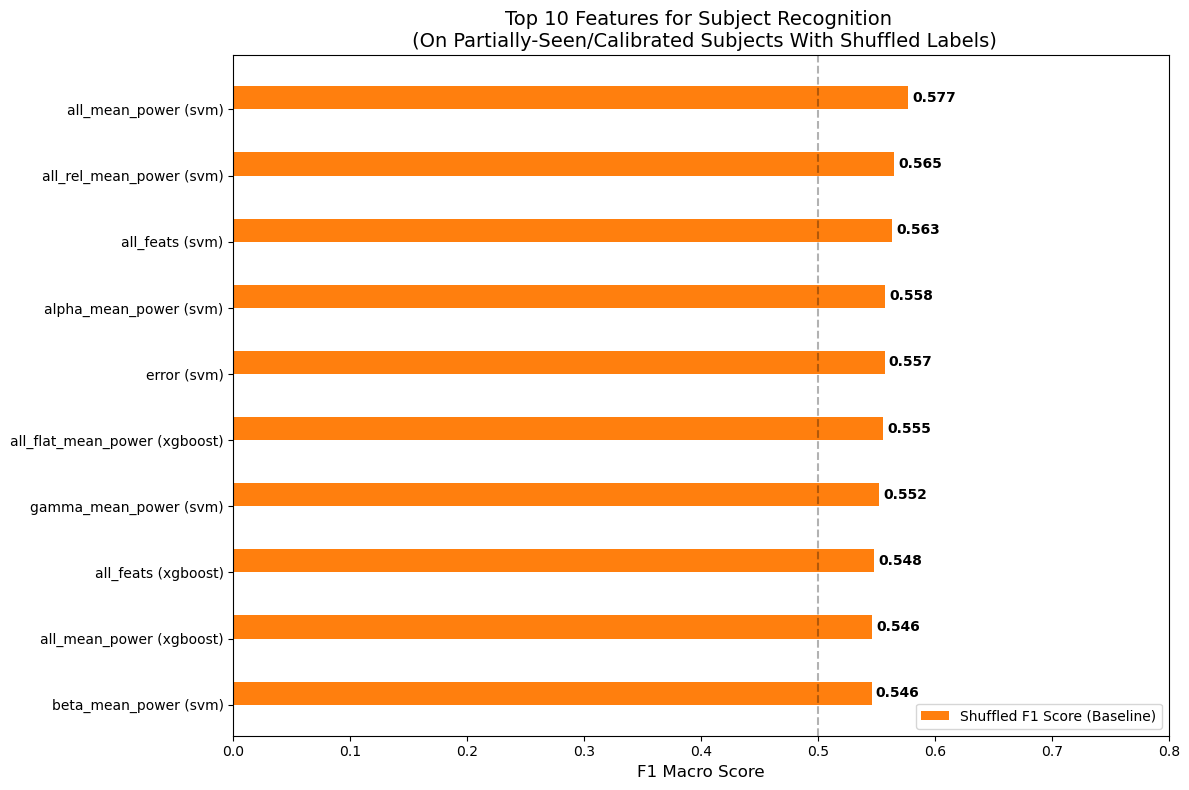

In [ ]:
# Cell: Top Features in LeavePartialGroupOut (Original vs. Shuffled)

# 1. Filter for the LeavePartialGroupOut condition
lpgo_results = merged[merged["cv"] == "LeavePartialGroupOut"].copy()

# 2. Sort by 'test_f1_macro_mean_shuff' to find features with the highest performance
# We'll take the top 10 performers
top_lpgo = lpgo_results.sort_values("test_f1_macro_mean_shuff", ascending=False).head(
    10
)

# 3. Prepare data for plotting
features = top_lpgo["feature"].tolist()
# orig_scores = top_lpgo["test_f1_macro_mean_orig"].tolist()
shuff_scores = top_lpgo["test_f1_macro_mean_shuff"].tolist()
# Combine feature name with classifier for clarity
feature_labels = [
    f"{feat} ({clf})"
    for feat, clf in zip(top_lpgo["feature"], top_lpgo["classifier_label"])
]

y = np.arange(len(feature_labels))  # label locations
height = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bars
# rects1 = ax.barh(y + height/2, orig_scores, height, label='Original F1 Score', color='#1f77b4')
rects2 = ax.barh(
    y - height / 2,
    shuff_scores,
    height,
    label="Shuffled F1 Score (Baseline)",
    color="#ff7f0e",
)

# 4. Add formatting
ax.set_xlabel("F1 Macro Score", fontsize=12)
ax.set_title(
    "Top 10 Features for Subject Recognition \n (On Partially-Seen/Calibrated Subjects With Shuffled Labels)",
    fontsize=14,
)
ax.set_yticks(y)
ax.set_yticklabels(feature_labels)
ax.legend(loc="lower right")
ax.set_xlim(0, 0.8)  # Adjust scale for visibility
ax.invert_yaxis()  # Put highest score at the top

# Add a vertical line at 0.5 for theoretical chance
ax.axvline(0.5, color="black", linestyle="--", alpha=0.3, label="Theoretical Chance")


# Add values to the bars
def add_labels(rects):
    for rect in rects:
        width = rect.get_width()
        ax.annotate(
            f"{width:.3f}",
            xy=(width, rect.get_y() + rect.get_height() / 2),
            xytext=(3, 0),  # 3 points horizontal offset
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
        )


# add_labels(rects1)
add_labels(rects2)

plt.tight_layout()
plt.show()

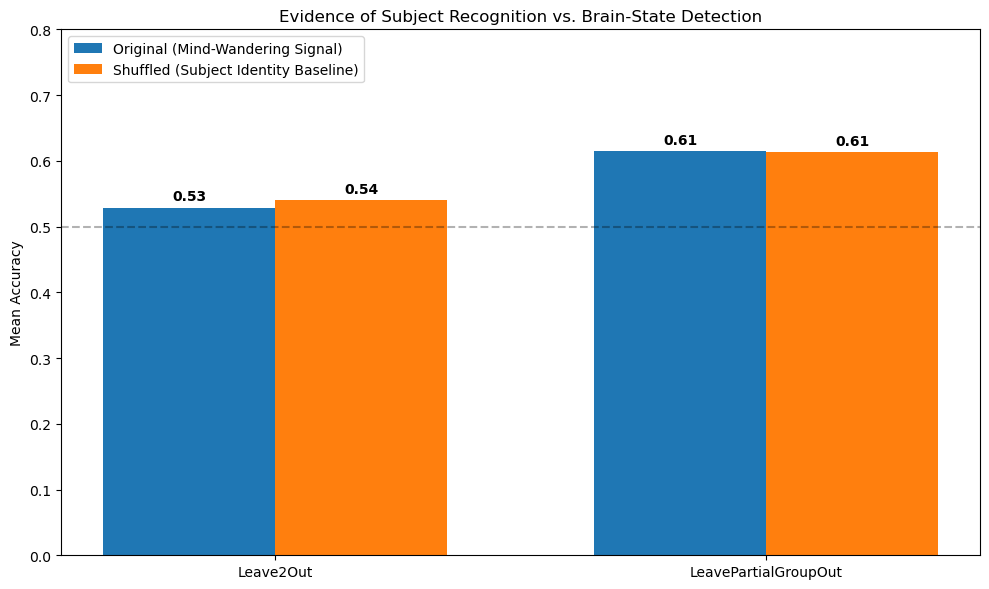

In [ ]:
# Cell: Visualization of Results

import matplotlib.pyplot as plt
import numpy as np

fig_size = (10, 6)

# This plot uses the global means for the two target CV methods
cv_summary = merged.groupby("cv")[
    ["test_accuracy_mean_orig", "test_accuracy_mean_shuff"]
].mean()

labels = cv_summary.index
orig_means = cv_summary["test_accuracy_mean_orig"]
shuff_means = cv_summary["test_accuracy_mean_shuff"]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=fig_size)
rects1 = ax.bar(
    x - width / 2,
    orig_means,
    width,
    label="Original (Mind-Wandering Signal)",
    color="#1f77b4",
)
rects2 = ax.bar(
    x + width / 2,
    shuff_means,
    width,
    label="Shuffled (Subject Identity Baseline)",
    color="#ff7f0e",
)

ax.set_ylabel("Mean Accuracy")
ax.set_title("Evidence of Subject Recognition vs. Brain-State Detection")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc="upper left")
ax.set_ylim(0, 0.8)
ax.axhline(0.5, color="black", linestyle="--", alpha=0.3, label="Chance (0.5)")


# Add values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )


autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()